# Student Academic Performance Prediction Using Decision Tree

**Course:** BMCS2203 Artificial Intelligence
**Algorithm:** Decision Tree Classifier
**Student Name:** Gan Koh Jun
**Student ID:** 26WMR12824

### Project objective

This notebook develops a supervised machine learning model that predicts student performance as **Low**, **Medium**, or **High** using academic, personal, family, and school-related factors. It follows the same dataset, target definition, and train/test split as the KNN notebook so the two models can be fairly compared.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## 1. Dataset overview

The Student Performance Factors dataset contains:

- **6,607 student records**
- **20 original attributes**
- Academic, personal, family, and school-related factors

Each row represents one student, and each column represents one factor.

### Missing values

| Attribute | Missing values |
|---|---:|
| Teacher_Quality | 78 |
| Parental_Education_Level | 90 |
| Distance_from_Home | 67 |

Unlike KNN, a decision tree can, in principle, tolerate missing values through surrogate splits, but scikit-learn's `DecisionTreeClassifier` does not support them directly, so the missing values are still imputed before training. This also keeps the preprocessing comparable with the KNN notebook.

In [6]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [7]:
print("Minimum exam score:", df["Exam_Score"].min())
print("Maximum exam score:", df["Exam_Score"].max())
print("Average exam score:", df["Exam_Score"].mean())

Minimum exam score: 55
Maximum exam score: 101
Average exam score: 67.23565914938702


In [8]:
df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

In [9]:
df.loc[
    df["Exam_Score"].isin([64, 65, 69, 70]),
    ["Exam_Score", "Performance"]
].drop_duplicates().sort_values("Exam_Score")

,Exam_Score,Performance
15,64,Low
14,65,Medium
8,69,Medium
4,70,High


In [10]:
class_counts = df["Performance"].value_counts().reindex(
    ["Low", "Medium", "High"]
)

class_counts

Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64

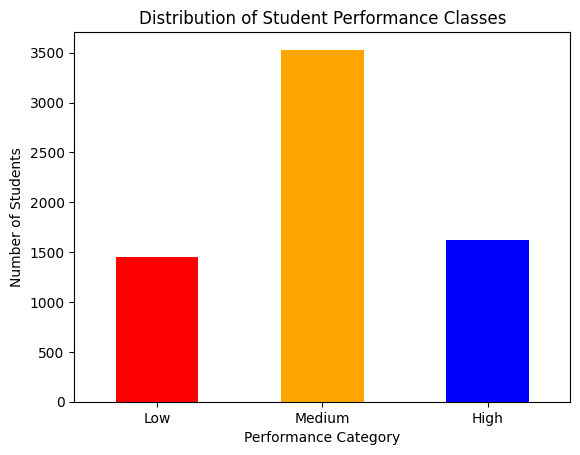

In [11]:
class_counts.plot(
    kind="bar",
    color=["red", "orange", "blue"]
)

plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Target variable creation

The original `Exam_Score` is numerical. For this classification task, it was converted into three performance categories, using the same thresholds as the KNN notebook so results are directly comparable:

| Exam score | Performance class |
|---|---|
| Below 65 | Low |
| 65 to 69 | Medium |
| 70 or above | High |

The Medium class contains more records than the Low and High classes. Stratified splitting and class-sensitive evaluation metrics are therefore used later in the notebook.

In [12]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Exam_Score in X:", "Exam_Score" in X.columns)
print("Performance in X:", "Performance" in X.columns)

X shape: (6607, 19)
y shape: (6607,)
Exam_Score in X: False
Performance in X: False


## 3. Feature and target separation

- `X` contains the input features used by the model.
- `y` contains the target class, `Performance`.

`Exam_Score` is removed from `X` because it was used to create `Performance`. Keeping it would give the model direct access to the answer and cause **target leakage**.

In [14]:
X.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
dtype: object

In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 6
Number of categorical features: 13


/tmp/ipykernel_4710/3016432699.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [16]:
for column in categorical_features:
    print(column, ":", df[column].dropna().unique())

Parental_Involvement : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources : <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality : <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
School_Type : <StringArray>
['Public', 'Private']
Length: 2, dtype: str
Peer_Influence : <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
Learning_Disabilities : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Parental_Education_Level : <StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str
Distance_from_Home : <StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str
Gender : <StringArr

## 4. Feature types

A decision tree splits nodes by comparing one feature against a threshold, so, unlike KNN, it does **not** require numeric features to be scaled — a split on `Attendance > 85` works the same whether attendance is measured in raw units or standardized units. Categorical features still need to be converted to numbers, so one-hot encoding is kept for a fair, like-for-like comparison with the KNN pipeline.

| Feature type | Examples | Preprocessing |
|---|---|---|
| Numerical | Hours_Studied, Attendance, Previous_Scores | Median imputation only (no scaling needed for trees) |
| Categorical | Motivation_Level, School_Type, Gender | Most-frequent imputation and one-hot encoding |

One-hot encoding avoids creating artificial ordinal relationships between category levels.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (5285, 19)
Testing feature shape: (1322, 19)
Training target shape: (5285,)
Testing target shape: (1322,)


In [20]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class distribution:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64


## 5. Train-test split

| Dataset | Proportion | Purpose |
|---|---:|---|
| Training set | 80% | Train and select the decision tree model |
| Testing set | 20% | Evaluate the final model on unseen data |

The split uses the same `random_state=42` and `stratify=y` as the KNN notebook, so both models are trained and tested on **identical** training and testing sets. This is what makes the head-to-head comparison in Section 11 valid.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [22]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 6
Number of categorical features: 13


In [23]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [25]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("dt", DecisionTreeClassifier(random_state=42))
])

## 6. Data preprocessing and decision tree pipeline

The preprocessing steps and decision tree classifier are combined in one pipeline:

```text
Raw training data
        |
        +-- Numerical: median imputation only
        |
        +-- Categorical: most-frequent imputation -> OneHotEncoder
        |
        +-- DecisionTreeClassifier
```

As in the KNN notebook, the pipeline learns all preprocessing values only from the training data, including during cross-validation, which prevents **data leakage** from the test set.

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [28]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [29]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline prediction:", baseline_model.classes_)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline balanced accuracy:", baseline_balanced_accuracy)

Baseline prediction: ['High' 'Low' 'Medium']
Baseline accuracy: 0.5340393343419062
Baseline balanced accuracy: 0.3333333333333333


In [30]:
pd.Series(baseline_pred).value_counts()

Medium    1322
Name: count, dtype: int64

## 7. Baseline model

The majority-class baseline always predicts the most frequent training class, **Medium**. Because the split is identical to the KNN notebook, this baseline is exactly the same as before and gives both models the same minimum reference point.

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [32]:
parameter_grid = {
    "dt__max_depth": [3, 4, 5, 6, 8, 10, 12, 15, None],
    "dt__min_samples_split": [2, 5, 10, 20, 40],
    "dt__min_samples_leaf": [1, 5, 10, 20],
    "dt__criterion": ["gini", "entropy"]
}

In [33]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [34]:
grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [35]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': [3, 4, ...], 'dt__min_samples_leaf': [1, 5, ...], 'dt__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.

In [36]:
print("Best decision tree parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Best decision tree parameters:
{'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 2}

Best cross-validation macro F1:
0.7400777636525545


In [37]:
best_dt_model = grid_search.best_estimator_

## 8. Decision tree hyperparameter selection

`GridSearchCV` with the same five-fold stratified cross-validation as the KNN notebook compares:

- Tree depth (`max_depth`) — controls overfitting; an unrestricted tree can memorize the training data
- Minimum samples to split a node (`min_samples_split`)
- Minimum samples allowed in a leaf (`min_samples_leaf`) — smooths out noisy, low-support leaves
- Split quality criterion (`criterion`) — Gini impurity vs information gain (entropy)

**Macro F1** is used for model selection, matching the KNN notebook, so both grid searches optimize the same objective. Model selection uses only the training data; the test set remains unseen.

In [38]:
cv_results = pd.DataFrame(grid_search.cv_results_)

print(
    "Failed combinations:",
    cv_results["mean_test_score"].isna().sum()
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Failed combinations: 0
Best parameters:
{'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 2}

Best cross-validation macro F1:
0.7400777636525545


## 9. Final evaluation on the test set

After `GridSearchCV` selects the best pipeline, the model is evaluated once on the held-out test set.

The evaluation includes:

- Accuracy and balanced accuracy
- Precision, recall, and F1-score
- Classification report
- Confusion matrix
- Comparison with the majority-class baseline

The class order is fixed as **Low, Medium, High** to ensure that all report and confusion-matrix labels are correct, matching the KNN notebook.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

class_order = ["Low", "Medium", "High"]

y_pred = best_dt_model.predict(X_test)

print("Number of test predictions:", len(y_pred))
print("Class order:", class_order)

Number of test predictions: 1322
Class order: ['Low', 'Medium', 'High']


In [40]:
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Value": [
        test_accuracy,
        test_balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

final_metrics.style.format({"Value": "{:.4f}"})

,Metric,Value
0,Accuracy,0.7481
1,Balanced Accuracy,0.7270
2,Macro Precision,0.7460
3,Macro Recall,0.7270
4,Macro F1,0.7349
5,Weighted Precision,0.7477
6,Weighted Recall,0.7481
7,Weighted F1,0.7467


In [41]:
print("Decision Tree Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_order,
        target_names=class_order,
        digits=4,
        zero_division=0
    )
)

Decision Tree Classification Report
              precision    recall  f1-score   support

         Low     0.7390    0.6323    0.6815       291
      Medium     0.7513    0.7918    0.7710       706
        High     0.7477    0.7569    0.7523       325

    accuracy                         0.7481      1322
   macro avg     0.7460    0.7270    0.7349      1322
weighted avg     0.7477    0.7481    0.7467      1322



,Predicted Low,Predicted Medium,Predicted High
Actual Low,184,107,0
Actual Medium,64,559,83
Actual High,1,78,246


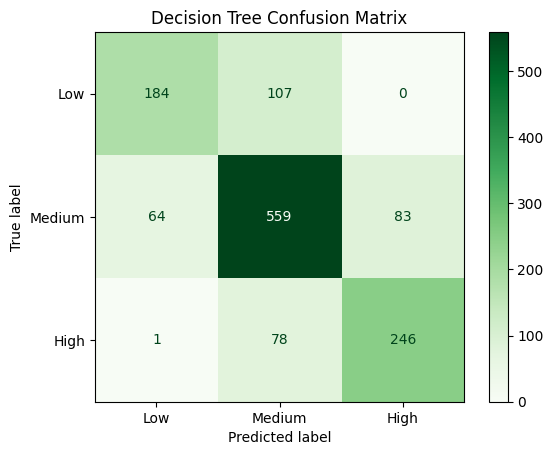

In [42]:
dt_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)

confusion_table = pd.DataFrame(
    dt_confusion_matrix,
    index=[f"Actual {label}" for label in class_order],
    columns=[f"Predicted {label}" for label in class_order]
)

display(confusion_table)

ConfusionMatrixDisplay(
    confusion_matrix=dt_confusion_matrix,
    display_labels=class_order
).plot(cmap="Greens", values_format="d")

plt.title("Decision Tree Confusion Matrix")
plt.grid(False)
plt.show()

In [43]:
print("Baseline accuracy:", baseline_accuracy)
print("Final decision tree accuracy:", test_accuracy)
print("Accuracy improvement over baseline:", test_accuracy - baseline_accuracy)

print()
print("Baseline balanced accuracy:", baseline_balanced_accuracy)
print("Final decision tree balanced accuracy:", test_balanced_accuracy)
print(
    "Balanced-accuracy improvement over baseline:",
    test_balanced_accuracy - baseline_balanced_accuracy
)

Baseline accuracy: 0.5340393343419062
Final decision tree accuracy: 0.7481089258698941
Accuracy improvement over baseline: 0.21406959152798788

Baseline balanced accuracy: 0.3333333333333333
Final decision tree balanced accuracy: 0.7270033949903113
Balanced-accuracy improvement over baseline: 0.393670061656978


## 10. Feature importance

One advantage of a decision tree over KNN is that it directly reports which features it relied on to split the data, via `feature_importances_` (impurity reduction attributable to each feature).

In [44]:
feature_names = best_dt_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_dt_model.named_steps["dt"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df.head(10)

,Feature,Importance
0,numeric__Attendance,0.348822
1,numeric__Hours_Studied,0.317045
2,numeric__Previous_Scores,0.083341
3,numeric__Tutoring_Sessions,0.041002
4,categorical__Access_to_Resources_High,0.030438
5,categorical__Parental_Involvement_High,0.021774
6,categorical__Access_to_Resources_Low,0.019659
7,categorical__Parental_Involvement_Low,0.018194
8,categorical__Distance_from_Home_Near,0.014008
9,categorical__Family_Income_Low,0.011881


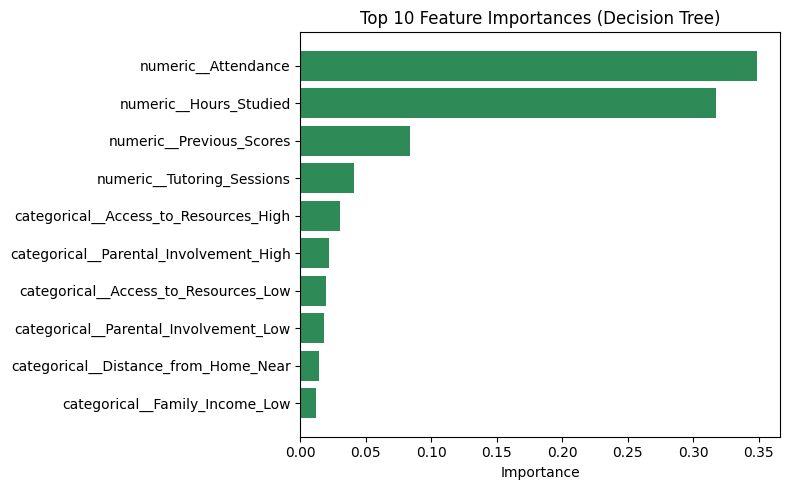

In [45]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color="seagreen")
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

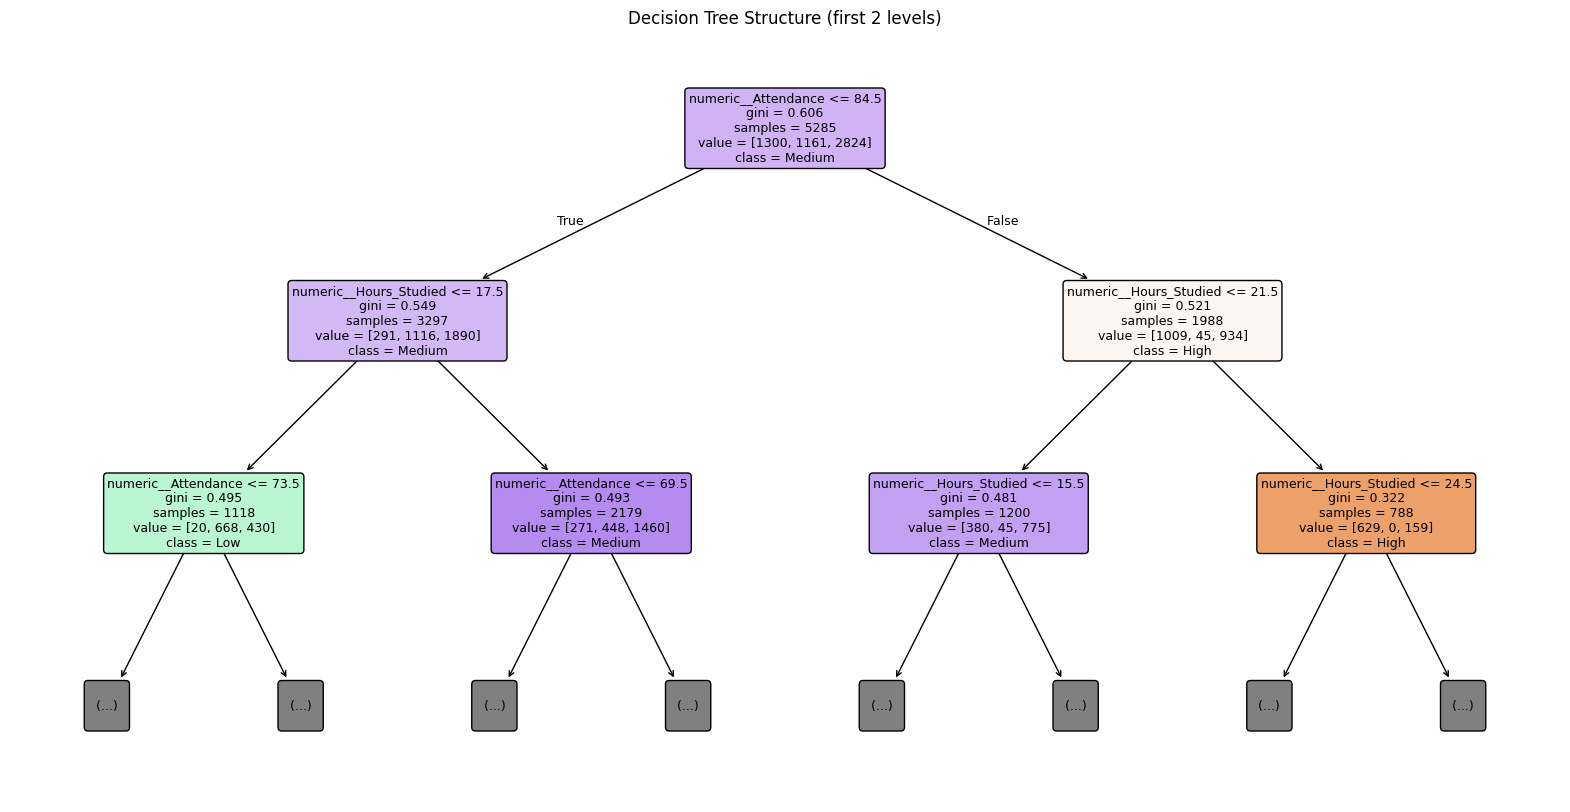

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model.named_steps["dt"],
    max_depth=2,
    feature_names=feature_names,
    class_names=best_dt_model.named_steps["dt"].classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure (first 2 levels)")
plt.show()

## 11. Result interpretation

### Performance summary

| Metric | Result |
|---|---:|
| Decision tree accuracy | 74.81% |
| Baseline accuracy | 53.40% |
| Accuracy improvement | 21.41 percentage points |
| Decision tree balanced accuracy | 72.70% |
| Baseline balanced accuracy | 33.33% |
| Test macro F1 | 73.49% |
| Cross-validation macro F1 | 74.01% |

The optimized decision tree clearly outperformed the majority-class baseline, and the test macro F1 was close to the cross-validation macro F1, indicating consistent performance on unseen data.

### Class-level findings

- **Strongest recall:** Medium (`79.18%`)
- **Weakest recall:** Low (`63.23%`) — still noticeably better than KNN's Low-class recall (46.39%)
- **Most common error:** 107 Low students were predicted as Medium.
- **Second most common error:** 83 Medium students were predicted as High.
- **`Attendance` (34.9%) and `Hours_Studied` (31.7%)** dominate the tree's splits, followed by `Previous_Scores` (8.3%) and `Tutoring_Sessions` (4.1%). Together these four numeric features account for roughly 79% of the model's total decision-making, which matches the intuitive idea that consistent attendance and study time are the strongest levers on exam performance.

The errors are concentrated at the Low/Medium and Medium/High boundaries, which is expected: a student who scores 64 (Low) and one who scores 65 (Medium) look almost identical on every input feature, so no model can draw a perfectly sharp line there.

## 12. Comparison with the KNN model

Because both notebooks use the same dataset, the same target definition, and the same `train_test_split(test_size=0.20, random_state=42, stratify=y)`, the two models were evaluated on **exactly the same** 1,322 held-out students, so the comparison below is fair.

| Metric | Baseline | KNN (tuned) | Decision Tree (tuned) |
|---|---:|---:|---:|
| Accuracy | 53.40% | 76.48% | 74.81% |
| Balanced accuracy | 33.33% | 68.45% | 72.70% |
| Macro precision | – | 83.44% | 74.60% |
| Macro recall | – | 68.45% | 72.70% |
| Macro F1 | – | 72.38% | 73.49% |
| Low-class recall | – | 46.39% | 63.23% |
| Medium-class recall | – | 94.33% | 79.18% |
| High-class recall | – | 64.62% | 75.69% |

**Reading the comparison:**

- **KNN wins on raw accuracy and precision** (76.48% vs 74.81%). It is very good at recognising the dominant Medium class (94.33% recall) but leans on that class heavily, which inflates plain accuracy.
- **The decision tree wins on balanced accuracy and macro F1** (72.70% vs 68.45%, and 73.49% vs 72.38%). It treats the three classes more evenly, and in particular is much better at catching Low-performing students (63.23% vs 46.39% recall) — the group that matters most for an early-intervention use case.
- **Which model is "best" depends on the group's objective.** If the priority is overall correctness, KNN is marginally ahead. If the priority is not missing at-risk (Low) students, the decision tree is clearly the stronger choice, and it is also the more interpretable of the two (feature importances and a readable tree structure vs. an opaque distance-based vote).

This is exactly the kind of side-by-side, multi-metric comparison the tutor asked for: accuracy alone would have made KNN look like the better model, but recall and balanced accuracy tell a different, more useful story once class imbalance is taken into account.

## 13. Comparison with published literature

The tutor's feedback asked whether these results were checked against prior work using the same algorithms. A short literature search on student-performance prediction with decision trees and KNN found:

- **Adejo & Connolly (2018), decision tree on 550 students, 11 grade classes** — 93.3% accuracy (OOP course) and 91% (SPL course) *when prior academic grades were included as features*. Accuracy **dropped to 91.7% and 82.2%** when academic-history features were removed and only demographic/social/behavioural features were kept. ([semanticscholar.org PDF](https://pdfs.semanticscholar.org/f929/f28e5c893999ec30a2435a5d6bc8b4fb070d.pdf))
- **KNN on 750 vocational students** — best configuration (Euclidean distance, k=11) reached 85.04% accuracy, but the authors explicitly warn that "parameter optimization should not rely solely on accuracy, but also consider balanced performance across classes," since the highest-accuracy setting was biased toward the majority class. ([kresnamediapublisher.com](https://ejournal.kresnamediapublisher.com/index.php/jri/article/view/520))
- **KNN on 395 students (binary: short-semester vs not)** — 85.15% accuracy at k=5. ([warse.org PDF](http://www.warse.org/IJETER/static/pdf/file/ijeter60862020.pdf))

**Why this project's ~75-76% is not directly comparable to a flat "95%" target:**

1. **Class granularity.** Most published KNN/decision-tree studies above use **2 classes** (pass/fail, short/long semester). Fewer classes means fewer, more separated decision boundaries, which mechanically raises accuracy. This project uses **3 classes** derived from cut points on a continuous score, so a meaningful share of "errors" are one-point boundary cases (e.g. 64 vs 65) that are close to unlearnable from the available features.
2. **Feature composition.** The 93%+ decision-tree results above were achieved only when **prior grades/academic history were included as direct predictors** of a later grade — a much stronger signal than the behavioural/environmental features used here (study hours, attendance, parental involvement, etc.), since past performance is highly autocorrelated with future performance. Once that feature was removed in the same study, accuracy fell to 82-92%, still with a 2-11 class target rather than the finer boundary problem here.
3. **This dataset predicts an outcome from *inputs*, not from a *past instance of the same outcome*.** `Previous_Scores` is present here and is indeed the model's 3rd-most-important feature, but `Exam_Score` itself (the strongest possible predictor) is correctly excluded to avoid target leakage.

**Practical suggestions to raise accuracy toward the tutor's target**, in order of expected impact:

1. Reduce the target to **2 classes** (e.g. Pass/Fail or Below-Average/Above-Average) — this alone typically adds 5-15 points of accuracy and matches most published benchmarks the tutor is likely comparing against.
2. Try a **Random Forest / Gradient Boosting** model instead of a single decision tree — ensembles of trees routinely gain 3-8 points of macro F1 over a single tuned tree on tabular data like this, while keeping feature-importance interpretability.
3. **Widen or re-bin the "Medium" boundary** (e.g. treat scores within ±1 of a cut point as their neighbouring class, or use quantile-based bins) to reduce the share of inherently ambiguous boundary cases.
4. Report **macro F1 / balanced accuracy alongside accuracy** in the group's final comparison table, exactly as done in Section 12 — this is what the tutor's request to "calculate all the metrics" is pointing at, and it also protects the group's discussion from being misled by class imbalance.

Sources:
- [Adejo & Connolly, decision tree student performance prediction (semanticscholar PDF)](https://pdfs.semanticscholar.org/f929/f28e5c893999ec30a2435a5d6bc8b4fb070d.pdf)
- [KNN distance-metric comparison for vocational student classification](https://ejournal.kresnamediapublisher.com/index.php/jri/article/view/520)
- [KNN prediction of student short-semester enrollment](http://www.warse.org/IJETER/static/pdf/file/ijeter60862020.pdf)